<a href="https://colab.research.google.com/github/2303A51908/Reinforecement-Learning---B12/blob/main/2303A51908_RL_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Episode:   1 | Train: 16.00 | Test: 11.00 | MeanTrain(100): 16.00 | MeanTest(100): 11.00 | Pol.Loss: 0.0016 | Val.Loss: 0.4582
Episode:  10 | Train: 36.00 | Test: 10.00 | MeanTrain(100): 20.30 | MeanTest(100): 9.40 | Pol.Loss: -0.0126 | Val.Loss: 0.1866
Episode:  20 | Train: 36.00 | Test: 123.00 | MeanTrain(100): 23.65 | MeanTest(100): 25.60 | Pol.Loss: -0.0014 | Val.Loss: 0.4439
Episode:  30 | Train: 136.00 | Test: 25.00 | MeanTrain(100): 32.40 | MeanTest(100): 32.67 | Pol.Loss: 0.0842 | Val.Loss: 0.1487
Episode:  40 | Train: 29.00 | Test: 72.00 | MeanTrain(100): 36.90 | MeanTest(100): 39.40 | Pol.Loss: -0.0034 | Val.Loss: 0.3976
Episode:  50 | Train: 34.00 | Test: 60.00 | MeanTrain(100): 43.06 | MeanTest(100): 57.04 | Pol.Loss: 0.0040 | Val.Loss: 0.2032
Episode:  60 | Train: 78.00 | Test: 151.00 | MeanTrain(100): 45.90 | MeanTest(100): 61.97 | Pol.Loss: 0.0119 | Val.Loss: 0.5526
Episode:  70 | Train: 186.00 | Test: 466.00 | MeanTrain(100): 50.27 | MeanTest(100): 73.23 | Pol.Loss: -0.

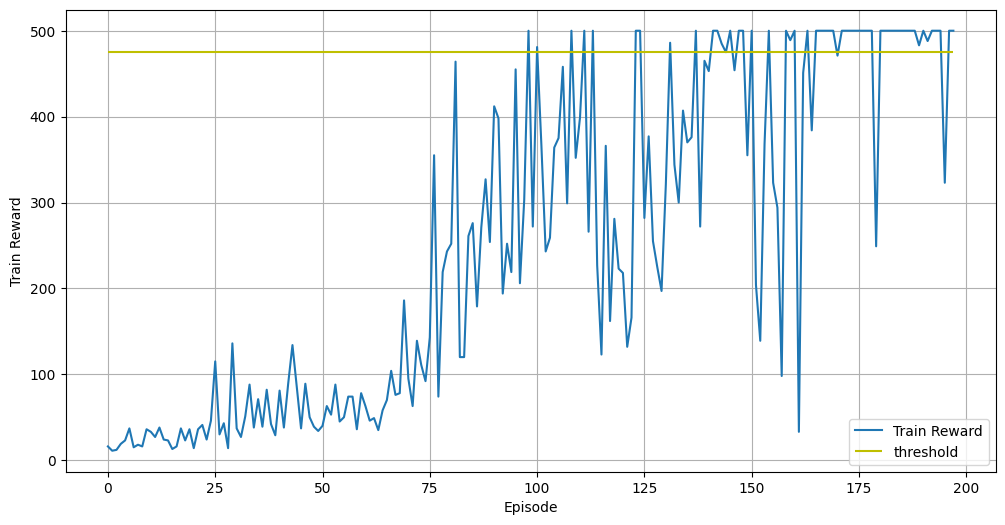

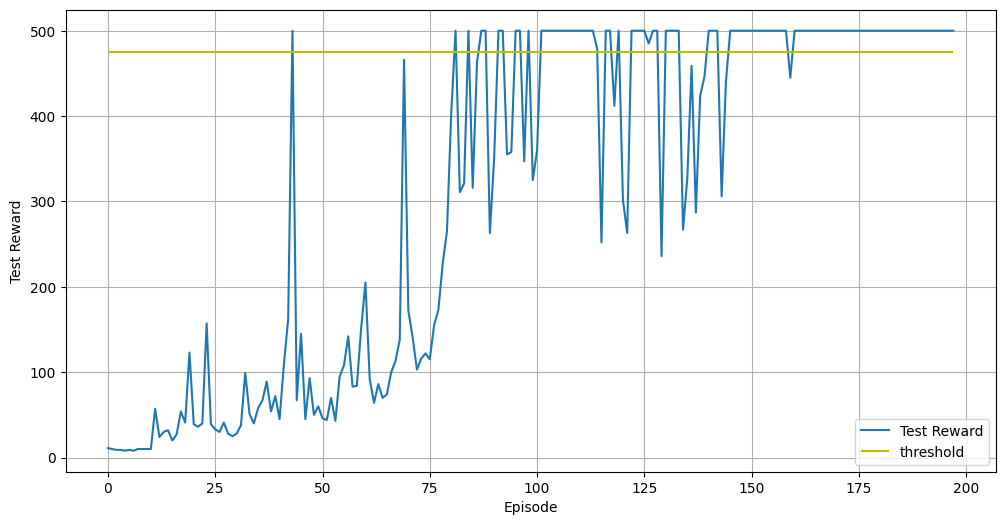

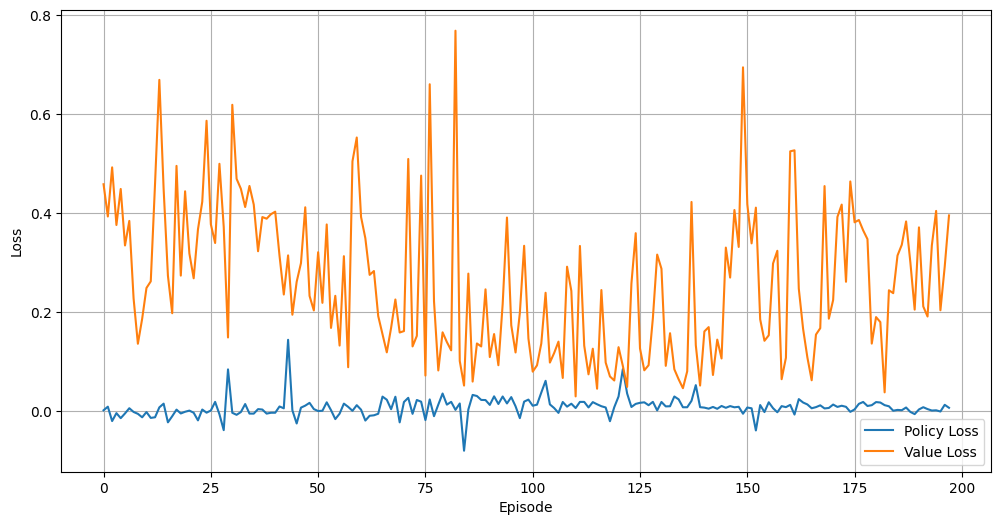

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.distributions import Categorical
import torch.nn.functional as F
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# -------------------------
# Backbone network for actor & critic
# -------------------------
class BackboneNetwork(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features, dropout):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, out_features)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# -------------------------
# Actor-Critic wrapper
# -------------------------
class ActorCritic(nn.Module):
    def __init__(self, actor: nn.Module, critic: nn.Module):
        super().__init__()
        self.actor = actor
        self.critic = critic

    def forward(self, state):
        # state: [B, obs_dim] or [obs_dim]
        action_logits = self.actor(state)
        value = self.critic(state)
        return action_logits, value

def create_agent(hidden_dim, dropout, env):
    n_obs = env.observation_space.shape[0]
    n_acts = env.action_space.n
    actor = BackboneNetwork(n_obs, hidden_dim, n_acts, dropout)
    critic = BackboneNetwork(n_obs, hidden_dim, 1, dropout)
    return ActorCritic(actor, critic)

# -------------------------
# Returns / advantages
# -------------------------
def calculate_returns(rewards, discount_factor, dtype=np.float32):
    R = 0.0
    returns = []
    for r in reversed(rewards):
        R = r + discount_factor * R
        returns.insert(0, R)
    returns = np.asarray(returns, dtype=dtype)
    # normalize
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return torch.tensor(returns, dtype=torch.float32)

def calculate_advantages(returns: torch.Tensor, values: torch.Tensor):
    # returns and values are torch.float32
    advantages = returns - values
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    return advantages

# -------------------------
# PPO surrogate & losses
# -------------------------
def surrogate_loss(old_log_probs, new_log_probs, epsilon, advantages):
    # inputs: tensors on same device, shape [batch]
    with torch.no_grad():
        adv_detached = advantages.detach()
    ratio = torch.exp(new_log_probs - old_log_probs)  # shape [batch]
    s1 = ratio * adv_detached
    s2 = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * adv_detached
    # return elementwise min
    return torch.min(s1, s2)

# -------------------------
# Data collection (single rollout)
# -------------------------
def forward_pass(env, agent, discount_factor, device):
    agent.train()
    states, actions, old_log_probs, values, rewards = [], [], [], [], []
    ep_reward = 0.0

    obs, _ = env.reset()  # gymnasium: obs, info
    done = False

    while not done:
        state_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)  # [1, obs_dim]
        action_logits, value_pred = agent(state_tensor)  # logits: [1, n_actions], value_pred: [1,1]
        action_prob = F.softmax(action_logits, dim=-1)
        dist = Categorical(action_prob)
        action = dist.sample().squeeze(0)             # scalar tensor (long)
        old_logp = dist.log_prob(action).squeeze(0).detach()   # scalar tensor
        # step env
        next_obs, reward, terminated, truncated, _ = env.step(int(action.item()))
        finished = bool(terminated or truncated)

        # store
        states.append(state_tensor.squeeze(0).cpu())        # store as CPU tensors for building dataset later
        actions.append(action.cpu())
        old_log_probs.append(old_logp.cpu())
        values.append(value_pred.squeeze(0).detach().cpu()) # value as CPU tensor [1] -> scalar
        rewards.append(float(reward))

        obs = next_obs
        ep_reward += reward
        done = finished

    # stack/format outputs
    states = torch.stack(states)                          # [T, obs_dim]
    actions = torch.stack(actions).long().squeeze(-1)     # [T]
    old_log_probs = torch.stack(old_log_probs).float()    # [T]
    values = torch.stack(values).squeeze(-1).float()      # [T]
    returns = calculate_returns(rewards, discount_factor) # tensor [T]
    advantages = calculate_advantages(returns, values)    # tensor [T]

    return ep_reward, states, actions, old_log_probs, advantages, returns

# -------------------------
# Update policy using PPO
# -------------------------
def update_policy(agent, states, actions, old_log_probs, advantages, returns,
                  optimizer, ppo_steps, epsilon, ent_coef, value_coef, device,
                  batch_size=128):
    agent.train()
    dataset = TensorDataset(states, actions, old_log_probs, advantages, returns)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    total_policy_loss = 0.0
    total_value_loss = 0.0
    total_batches = 0

    for _ in range(ppo_steps):
        for batch in loader:
            b_states, b_actions, b_old_log_probs, b_adv, b_returns = batch
            b_states = b_states.to(device)
            b_actions = b_actions.to(device)
            b_old_log_probs = b_old_log_probs.to(device)
            b_adv = b_adv.to(device)
            b_returns = b_returns.to(device)

            # forward
            logits, value_pred = agent(b_states)    # logits: [B, A], value_pred: [B,1]
            value_pred = value_pred.squeeze(-1)     # [B]
            probs = F.softmax(logits, dim=-1)
            dist = Categorical(probs)
            new_log_probs = dist.log_prob(b_actions)       # [B]
            entropy = dist.entropy().mean()                # scalar

            # surrogate (elementwise), then mean
            surr = surrogate_loss(b_old_log_probs, new_log_probs, epsilon, b_adv)  # [B]
            policy_loss = -surr.mean()
            value_loss = F.smooth_l1_loss(value_pred, b_returns)  # mean by default

            # combine and backward once
            total_loss = policy_loss + value_coef * value_loss - ent_coef * entropy

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            total_policy_loss += policy_loss.item()
            total_value_loss += value_loss.item()
            total_batches += 1

    # Return average losses (per batch)
    avg_policy_loss = total_policy_loss / max(1, total_batches)
    avg_value_loss = total_value_loss / max(1, total_batches)
    return avg_policy_loss, avg_value_loss

# -------------------------
# Evaluation (deterministic greedy action)
# -------------------------
def evaluate(env, agent, device):
    agent.eval()
    obs, _ = env.reset()
    done = False
    ep_reward = 0.0
    while not done:
        state_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            logits, _ = agent(state_tensor)
            probs = F.softmax(logits, dim=-1)
            action = torch.argmax(probs, dim=-1).item()
        obs, reward, terminated, truncated, _ = env.step(int(action))
        done = bool(terminated or truncated)
        ep_reward += reward
    return ep_reward

# -------------------------
# Plot helpers
# -------------------------
def plot_rewards(rewards, threshold, label):
    plt.figure(figsize=(12, 6))
    plt.plot(rewards, label=label)
    plt.xlabel('Episode')
    plt.ylabel(label)
    if threshold is not None:
        plt.hlines(threshold, 0, max(1, len(rewards)-1), color='y', label='threshold')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

def plot_losses(policy_losses, value_losses):
    plt.figure(figsize=(12, 6))
    plt.plot(policy_losses, label='Policy Loss')
    plt.plot(value_losses, label='Value Loss')
    plt.xlabel('Episode')
    plt.ylabel('Loss')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

# -------------------------
# Runner
# -------------------------
def run_ppo():
    # -- Hyperparameters
    max_episodes = 500
    gamma = 0.99
    reward_thresh = 475
    print_interval = 10
    PPO_STEPS = 8
    N_TRIALS = 100
    epsilon = 0.2
    entropy_coef = 0.01
    value_coef = 0.5
    hidden_dim = 64
    dropout = 0.2
    lr = 1e-3
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    batch_size = 128

    # -- Envs
    env_train = gym.make('CartPole-v1')
    env_test = gym.make('CartPole-v1')

    # -- Agent and optimizer
    agent = create_agent(hidden_dim, dropout, env_train).to(device)
    optimizer = optim.Adam(agent.parameters(), lr=lr)

    train_rewards, test_rewards, policy_losses, value_losses = [], [], [], []

    for episode in range(1, max_episodes + 1):
        train_reward, states, actions, old_log_probs, advantages, returns = forward_pass(
            env_train, agent, gamma, device
        )

        pol_loss, val_loss = update_policy(
            agent, states, actions, old_log_probs, advantages, returns,
            optimizer, PPO_STEPS, epsilon, entropy_coef, value_coef, device, batch_size=batch_size
        )

        test_reward = evaluate(env_test, agent, device)

        train_rewards.append(train_reward)
        test_rewards.append(test_reward)
        policy_losses.append(pol_loss)
        value_losses.append(val_loss)

        mean_train_r = np.mean(train_rewards[-N_TRIALS:]) if len(train_rewards) >= 1 else 0.0
        mean_test_r = np.mean(test_rewards[-N_TRIALS:]) if len(test_rewards) >= 1 else 0.0

        if episode % print_interval == 0 or episode == 1:
            print(f'Episode: {episode:3} | Train: {train_reward:.2f} | Test: {test_reward:.2f} | '
                  f'MeanTrain({N_TRIALS}): {mean_train_r:.2f} | MeanTest({N_TRIALS}): {mean_test_r:.2f} | '
                  f'Pol.Loss: {pol_loss:.4f} | Val.Loss: {val_loss:.4f}')

        if mean_test_r >= reward_thresh:
            print(f'Solved in {episode} episodes! Mean test reward {mean_test_r:.2f}')
            break

    plot_rewards(train_rewards, reward_thresh, 'Train Reward')
    plot_rewards(test_rewards, reward_thresh, 'Test Reward')
    plot_losses(policy_losses, value_losses)

# Run
if __name__ == "__main__":
    run_ppo()